# tmp — aug25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
from base.helper import schedule_t_train

In [41]:
t_trains = schedule_t_train(
    n_iters=160_000,
    val_init=8,
    val_final=64,
    n_stages=4,
    mode='geometric',
    balance=True,
)

In [42]:
t_trains

array([ 8,  8,  8, ..., 64, 64, 64])

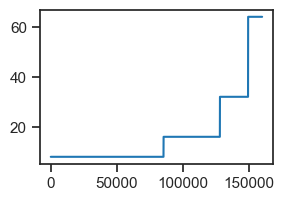

In [43]:
plot(t_trains)
plt.show()

In [26]:
collections.Counter(t_trains)

Counter({8: 40000, 14: 40000, 33: 40000, 64: 40000})

In [3]:
from base.helper import conv_arithmetic

In [5]:
df = conv_arithmetic(
    deconv=True,
    input_size=6,
    output_size=32,
    stride=4,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      6
1  deconv     False     output_size     32
2  deconv      True     kernel_size     12
3  deconv     False          stride      4
4  deconv     False         padding      0
5  deconv     False  output_padding      0

In [31]:
256 / 81

3.1604938271604937

In [6]:
df = conv_arithmetic(
    deconv=True,
    input_size=5,
    output_size=32,
    stride=4,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      5
1  deconv     False     output_size     32
2  deconv      True     kernel_size     16
3  deconv     False          stride      4
4  deconv     False         padding      0
5  deconv     False  output_padding      0

In [17]:
df = conv_arithmetic(
    deconv=True,
    input_size=6,
    output_size=32,
    stride=4,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      6
1  deconv     False     output_size     32
2  deconv      True     kernel_size     12
3  deconv     False          stride      4
4  deconv     False         padding      0
5  deconv     False  output_padding      0

In [57]:
df = conv_arithmetic(
    deconv=True,
    input_size=13,
    output_size=28,
    stride=2,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size     13
1  deconv     False     output_size     28
2  deconv      True     kernel_size      4
3  deconv     False          stride      2
4  deconv     False         padding      0
5  deconv     False  output_padding      0

In [61]:
df = conv_arithmetic(
    deconv=True,
    input_size=13,
    output_size=28,
    stride=2,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size     13
1  deconv     False     output_size     28
2  deconv      True     kernel_size      4
3  deconv     False          stride      2
4  deconv     False         padding      0
5  deconv     False  output_padding      0

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('Kyoto-wht+translate', model_type, 'ngd|lin')

cfg_vae['feeder_cfg'] = {'iters_per_epoch': 1000}

cfg_tr['epochs'] = 150
cfg_tr['batch_size'] = 200

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

150000

In [5]:
epoch = 123

tr.feeder_trn.set_epoch(epoch=epoch)

for i in tqdm(range(len(tr.feeder_trn))):
    gstep = epoch * len(tr.feeder_trn) + i
    tr.feeder_trn.set_rng(gstep)
    _ = tr.feeder_trn.get_batch_data(i)

    for t in range(32):
        x, *_ = tr.feeder_trn.step()

100%|███████████████████████████████████████| 1000/1000 [00:13<00:00, 72.94it/s]
